In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

data = data.dropna(
    subset=["TotalCharges"]
).copy()

data["ChurnFlag"] = data["Churn"].map({
    "Yes": 1,
    "No": 0
})

print("Customer data loaded successfully!")
print("Customers:", len(data))

Customer data loaded successfully!
Customers: 7032


In [3]:
# Customer and Revenue KPIs

total_customers = len(data)

churned_customers = data["ChurnFlag"].sum()

active_customers = total_customers - churned_customers

retention_rate = (
    active_customers / total_customers
) * 100

churn_rate = (
    churned_customers / total_customers
) * 100

total_monthly_revenue = data["MonthlyCharges"].sum()

average_monthly_charge = data["MonthlyCharges"].mean()

average_tenure = data["tenure"].mean()

print("INTEGRATED KPI SUMMARY")
print("----------------------")
print("Total Customers:", total_customers)
print("Active Customers:", active_customers)
print("Churned Customers:", churned_customers)
print("Retention Rate:", round(retention_rate, 2), "%")
print("Churn Rate:", round(churn_rate, 2), "%")
print("Monthly Revenue:", round(total_monthly_revenue, 2))
print("Average Monthly Charge:", round(average_monthly_charge, 2))
print("Average Tenure:", round(average_tenure, 2), "months")

INTEGRATED KPI SUMMARY
----------------------
Total Customers: 7032
Active Customers: 5163
Churned Customers: 1869
Retention Rate: 73.42 %
Churn Rate: 26.58 %
Monthly Revenue: 455661.0
Average Monthly Charge: 64.8
Average Tenure: 32.42 months


In [4]:
# Retention and CLV Analytics

data["EstimatedCLV"] = (
    data["MonthlyCharges"] * average_tenure
)

clv_threshold = data["EstimatedCLV"].quantile(0.75)

data["CLVGroup"] = np.where(
    data["EstimatedCLV"] >= clv_threshold,
    "High-Value",
    "Standard-Value"
)

high_value_customers = (
    data["CLVGroup"] == "High-Value"
).sum()

average_clv = data["EstimatedCLV"].mean()

print("RETENTION & CLV")
print("----------------")
print("High-Value Customers:", high_value_customers)
print("Average Estimated CLV:", round(average_clv, 2))
print("CLV Threshold:", round(clv_threshold, 2))

RETENTION & CLV
----------------
High-Value Customers: 1758
Average Estimated CLV: 2100.87
CLV Threshold: 2913.5


In [5]:
# Predictive Customer Risk

features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X = data[features]
y = data["ChurnFlag"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

risk_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

risk_model.fit(X_scaled, y)

data["ChurnProbability"] = risk_model.predict_proba(
    X_scaled
)[:, 1]

data["RiskLevel"] = np.where(
    data["ChurnProbability"] >= 0.70,
    "High Risk",
    np.where(
        data["ChurnProbability"] >= 0.40,
        "Medium Risk",
        "Low Risk"
    )
)

high_risk_customers = (
    data["RiskLevel"] == "High Risk"
).sum()

print("PREDICTIVE RISK")
print("----------------")
print("High-Risk Customers:", high_risk_customers)
print("Risk model generated successfully!")

PREDICTIVE RISK
----------------
High-Risk Customers: 222
Risk model generated successfully!


In [6]:
# Revenue Forecasting Module

revenue_by_tenure = (
    data.groupby("tenure")["TotalCharges"]
    .sum()
    .reset_index()
)

revenue_by_tenure.columns = [
    "Tenure",
    "Revenue"
]

# Simple moving-average forecast
window = 3

recent_revenue = revenue_by_tenure["Revenue"].tail(window)

forecast_value = recent_revenue.mean()

print("FORECASTING MODULE")
print("------------------")
print("Recent average revenue:",
      round(forecast_value, 2))

print("Forecasting module completed!")

FORECASTING MODULE
------------------
Recent average revenue: 1210400.85
Forecasting module completed!


In [7]:
# Unified Business Intelligence Summary

bi_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Active Customers",
        "Churned Customers",
        "Retention Rate",
        "Churn Rate",
        "Monthly Revenue",
        "Average Monthly Charge",
        "Average Tenure",
        "Average Estimated CLV",
        "High-Value Customers",
        "High-Risk Customers",
        "Revenue Forecast Proxy"
    ],
    "Value": [
        total_customers,
        active_customers,
        churned_customers,
        retention_rate,
        churn_rate,
        total_monthly_revenue,
        average_monthly_charge,
        average_tenure,
        average_clv,
        high_value_customers,
        high_risk_customers,
        forecast_value
    ]
})

bi_summary = bi_summary.round(2)

bi_summary

,Metric,Value
0,Total Customers,7032.00
1,Active Customers,5163.00
2,Churned Customers,1869.00
3,Retention Rate,73.42
4,Churn Rate,26.58
5,Monthly Revenue,455661.00
6,Average Monthly Charge,64.80
7,Average Tenure,32.42
8,Average Estimated CLV,2100.87
9,High-Value Customers,1758.00


In [8]:
bi_summary.to_csv(
    "day42_integrated_bi_summary.csv",
    index=False
)

print("Integrated BI summary saved successfully!")

Integrated BI summary saved successfully!


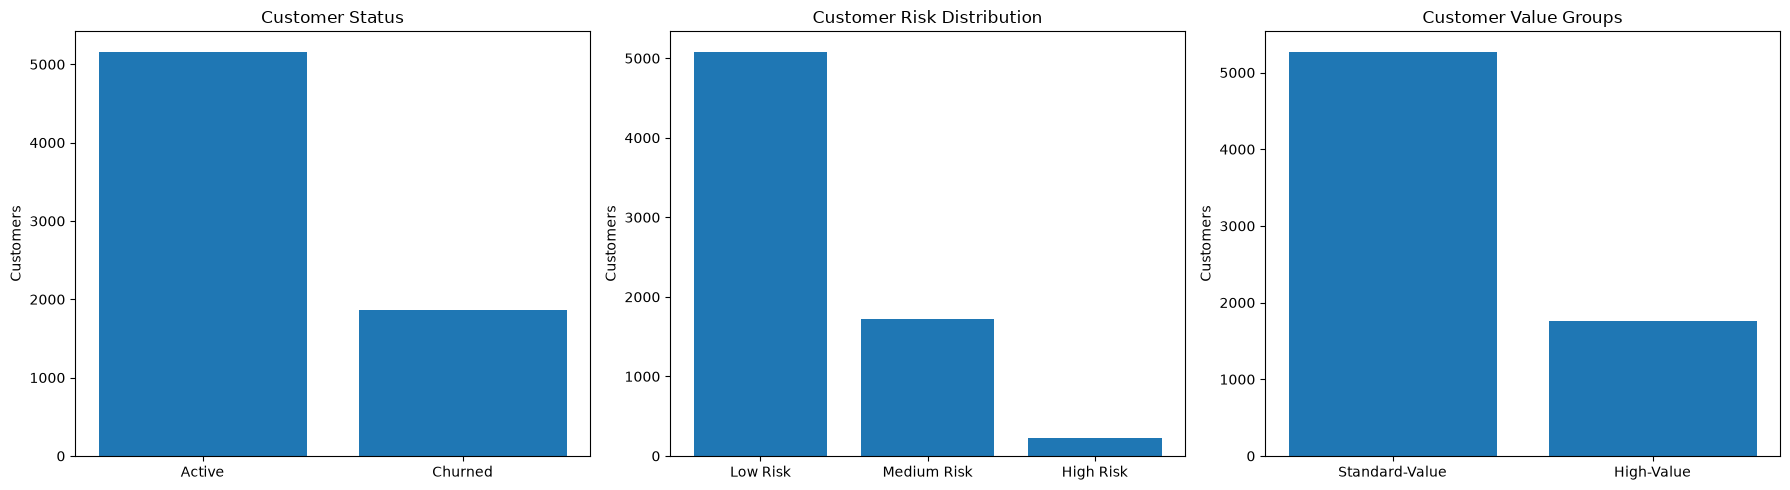

Executive BI dashboard created successfully!


In [9]:
# Executive BI Visualization

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Customer status
axes[0].bar(
    ["Active", "Churned"],
    [active_customers, churned_customers]
)
axes[0].set_title("Customer Status")
axes[0].set_ylabel("Customers")

# Risk distribution
risk_counts = data["RiskLevel"].value_counts()
axes[1].bar(
    risk_counts.index,
    risk_counts.values
)
axes[1].set_title("Customer Risk Distribution")
axes[1].set_ylabel("Customers")

# CLV groups
clv_counts = data["CLVGroup"].value_counts()
axes[2].bar(
    clv_counts.index,
    clv_counts.values
)
axes[2].set_title("Customer Value Groups")
axes[2].set_ylabel("Customers")

plt.tight_layout()

plt.savefig("day42_executive_bi_dashboard.png", dpi=300)
plt.show()

print("Executive BI dashboard created successfully!")

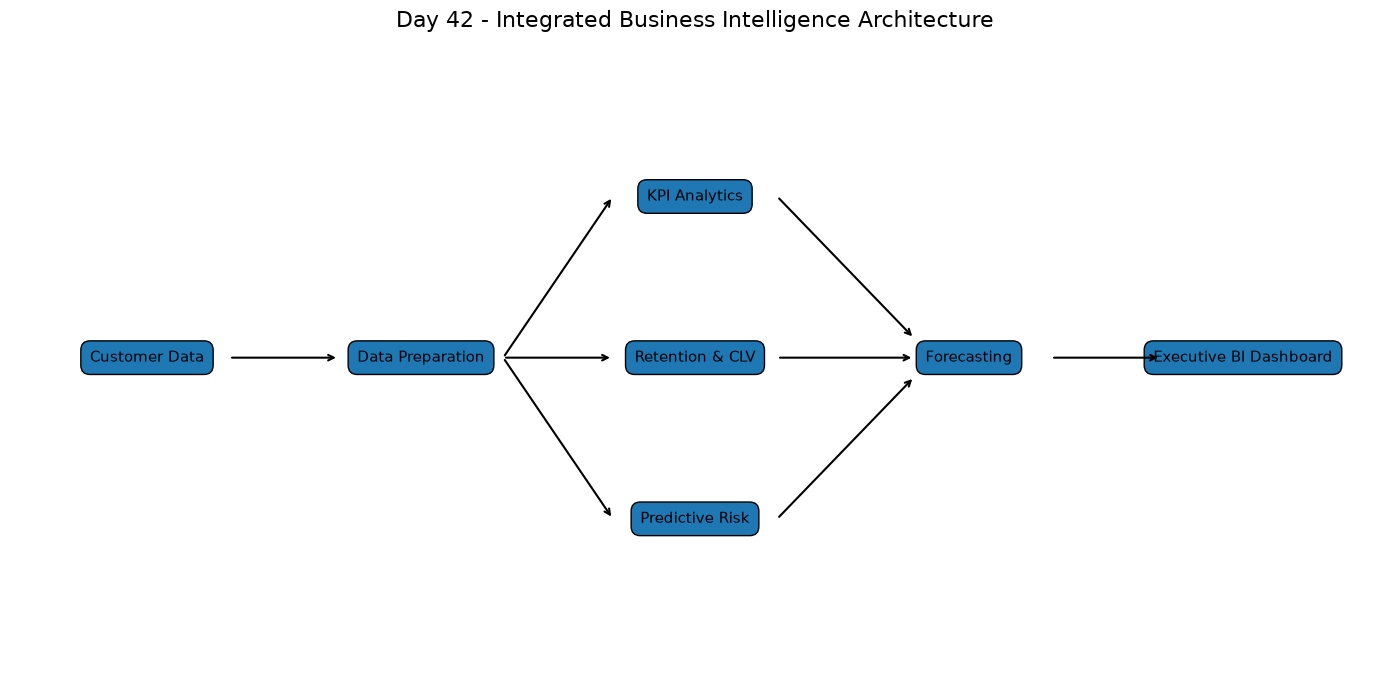

BI architecture diagram created successfully!


In [10]:
# Day 42 - BI Architecture Workflow

fig, ax = plt.subplots(figsize=(14, 7))

ax.axis("off")

steps = [
    ("Customer Data", 0.10, 0.50),
    ("Data Preparation", 0.30, 0.50),
    ("KPI Analytics", 0.50, 0.75),
    ("Retention & CLV", 0.50, 0.50),
    ("Predictive Risk", 0.50, 0.25),
    ("Forecasting", 0.70, 0.50),
    ("Executive BI Dashboard", 0.90, 0.50)
]

for text, x, y in steps:
    ax.text(
        x, y, text,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.6", edgecolor="black")
    )

# Arrows
arrows = [
    ((0.16, 0.50), (0.24, 0.50)),
    ((0.36, 0.50), (0.44, 0.75)),
    ((0.36, 0.50), (0.44, 0.50)),
    ((0.36, 0.50), (0.44, 0.25)),
    ((0.56, 0.75), (0.66, 0.53)),
    ((0.56, 0.50), (0.66, 0.50)),
    ((0.56, 0.25), (0.66, 0.47)),
    ((0.76, 0.50), (0.84, 0.50))
]

for start, end in arrows:
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(arrowstyle="->", lw=1.5)
    )

ax.set_title(
    "Day 42 - Integrated Business Intelligence Architecture",
    fontsize=16
)

plt.tight_layout()
plt.savefig("day42_bi_architecture.png", dpi=300)
plt.show()

print("BI architecture diagram created successfully!")

In [12]:
# Day 42 - Business Intelligence Report

report = f"""
DAY 42 - INTEGRATED BUSINESS INTELLIGENCE REPORT
================================================

1. EXECUTIVE SUMMARY
--------------------
This project integrates customer KPIs, retention and CLV analytics,
predictive churn risk scoring, and revenue forecasting into a unified
business intelligence workflow.

2. KEY BUSINESS METRICS
-----------------------
Total Customers: {total_customers}
Active Customers: {active_customers}
Churned Customers: {churned_customers}
Retention Rate: {retention_rate:.2f}%
Churn Rate: {churn_rate:.2f}%
Monthly Revenue: {total_monthly_revenue:.2f}
Average Monthly Charge: {average_monthly_charge:.2f}
Average Tenure: {average_tenure:.2f} months

3. CUSTOMER VALUE
-----------------
Average Estimated CLV: {average_clv:.2f}
High-Value Customers: {high_value_customers}

CLV is used as an educational proxy based on monthly charges and
average tenure. It should not be interpreted as actual profit.

4. PREDICTIVE RISK
------------------
High-Risk Customers: {high_risk_customers}

The predictive module estimates customer churn probability using
tenure, monthly charges, and total charges.

5. FORECASTING
--------------
Revenue Forecast Proxy: {forecast_value:.2f}

The forecasting component uses a tenure-based revenue proxy.
The dataset does not contain actual transaction dates, so this is
a learning-oriented forecasting demonstration rather than a true
time-series business forecast.

6. BUSINESS INTELLIGENCE IMPACT
-------------------------------
The integrated workflow helps decision-makers:
- Monitor customer and revenue KPIs
- Identify high-value customers
- Identify customers with higher estimated churn risk
- Understand retention patterns
- Support revenue planning
- Combine multiple analytics modules in one decision-support workflow

7. KEY TRADE-OFFS
-----------------
Predictive risk scores depend on the available features and should
be validated with newer real-world customer data.

CLV is an estimated proxy rather than a complete profitability model.

Forecasting is limited because the dataset does not contain actual
historical dates or transaction-level revenue records.

8. CONCLUSION
-------------
Day 42 demonstrates how separate analytics modules can be integrated
into a centralized business intelligence workflow for executive
decision support.
"""

with open("day42_business_intelligence_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

print("Business intelligence report created successfully!")

Business intelligence report created successfully!


In [14]:
# Day 42 - Week 6 Reflection

reflection = """
WEEK 6 REFLECTION
=================

This week focused on transforming individual data science models into
an integrated business intelligence workflow.

I worked with customer KPIs, retention analytics, CLV estimation,
predictive churn risk scoring, revenue forecasting, and executive
dashboard visualization.

The most important learning was understanding how different analytics
modules can work together to support business decision-making rather
than operating as separate models.

I also learned that real-world analytics requires understanding the
limitations of the available data. For example, the dataset used in
this project does not contain actual historical dates, so the
forecasting component is a learning-oriented proxy rather than a
production forecasting system.

The predictive risk model also depends on a limited set of customer
features, which means its results should be validated with richer and
more recent business data before making operational decisions.

Overall, Week 6 improved my understanding of how data science,
predictive analytics, forecasting, visualization, and business
intelligence can be combined into one decision-support workflow.

The project helped me move from building individual machine learning
models toward thinking about complete analytics systems and their
real-world business applications.
"""

with open("day42_week6_reflection.txt", "w", encoding="utf-8") as f:
    f.write(reflection)

print("Week 6 reflection created successfully!")

Week 6 reflection created successfully!
